In [115]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [116]:
def configure_plots():
    """Set up publication-quality plot defaults."""
    plt.rcParams.update({
        # Figure
        "figure.figsize": (6, 4),
        "figure.dpi": 150,
        "figure.facecolor": "white",
        # Fonts
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        # Lines
        "lines.linewidth": 1.5,
        "lines.markersize": 5,
        # Axes
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "axes.grid.which": "major",
        # Grid
        "grid.alpha": 0.3,
        "grid.linewidth": 0.5,
        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        # Legend
        "legend.framealpha": 0.9,
        "legend.edgecolor": "0.8",
        "legend.fontsize": 10,
        # Saving
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
})

[278.29997174   2.02783981]


/tmp/ipykernel_43606/2342004374.py:14: RuntimeWarning: overflow encountered in power
  return A*(x**(-tau))


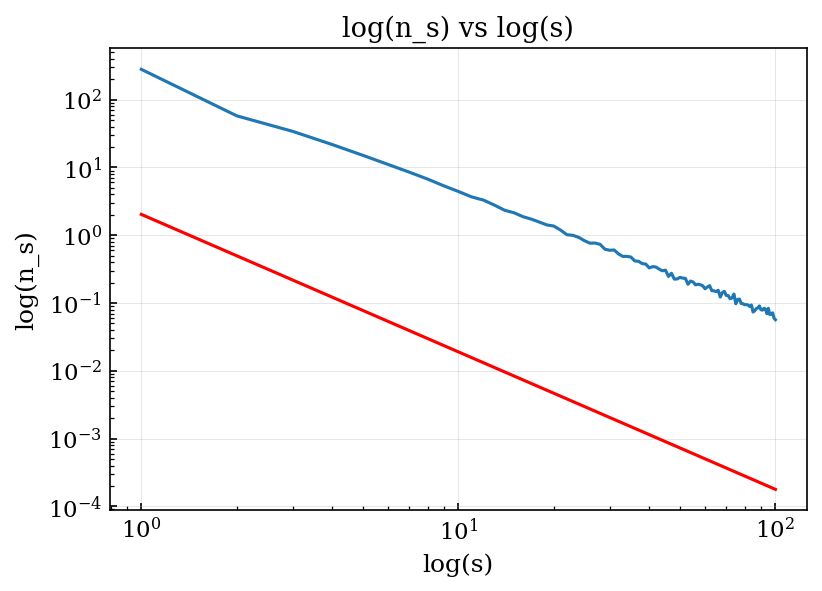

In [117]:
configure_plots()
data_array = np.loadtxt("meow.txt")
s = data_array[0:100,0]
n_s = data_array[0:100,1]
plt.figure()
plt.plot(s,n_s, label = "data")
plt.xscale("log")
plt.yscale("log")
plt.ylabel("log(n_s)")
plt.xlabel("log(s)")
plt.title("log(n_s) vs log(s)")

def func(x, A, tau):
    return A*(x**(-tau))

yur = sp.optimize.curve_fit(func, s, n_s)
print(yur[0])
plt.plot(s, func(s,yur[0][1],yur[0][1]), color = 'red', label = "fit")

/tmp/ipykernel_43606/2899372024.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_43606/2899372024.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


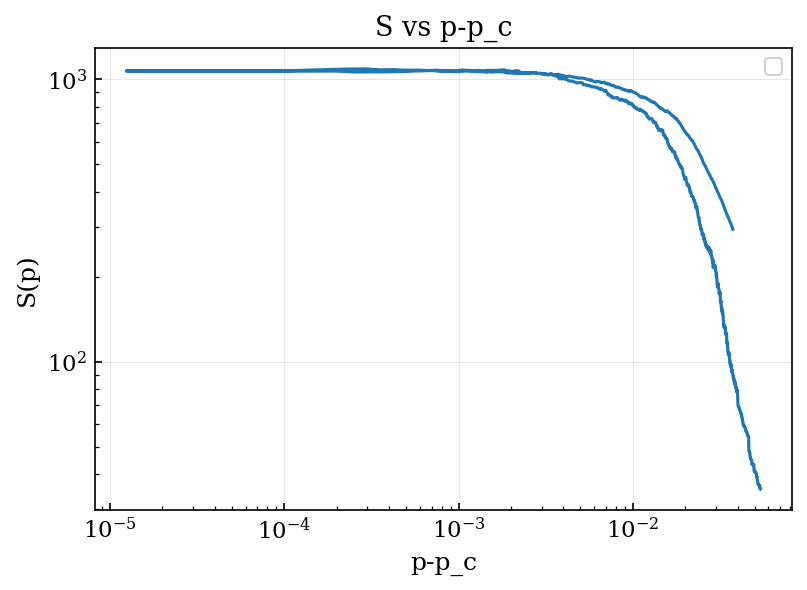

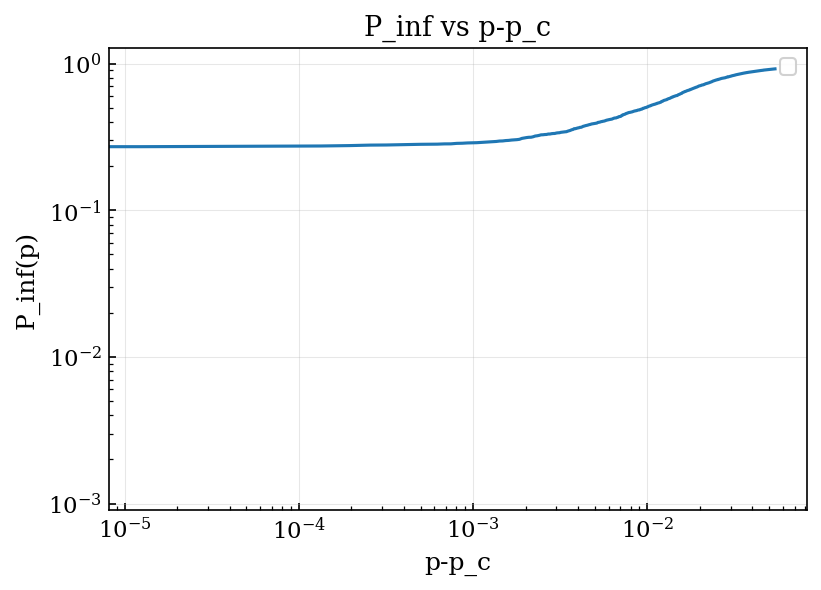

In [118]:
pc = 0.5927

mean58 = np.loadtxt("meancluster58.txt")
mean60 = np.loadtxt("meancluster60.txt")

meanP60 = abs(mean60[5000:6500,0] - pc)
meanSize60 = mean60[5000:6500,1]

pinf58 = np.loadtxt("pinf58.txt")
pinf60 = np.loadtxt("pinf60.txt")

pinfP60 = pinf60[5000:6500,0] - pc
pinfyep60 = pinf60[5000:6500,1]


plt.figure()

plt.plot(meanP60, meanSize60)
plt.title("S vs p-p_c")
plt.ylabel("S(p)")
plt.xlabel("p-p_c")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.figure()
plt.title("P_inf vs p-p_c")
plt.plot(pinfP60, pinfyep60)
plt.xscale("log")
plt.yscale("log")
plt.ylabel("P_inf(p)")
plt.xlabel("p-p_c")
plt.legend()


(array([0.41666732]), array([[0.00292153]])) (array([1.86427328]), array([[7.26708e-05]]))


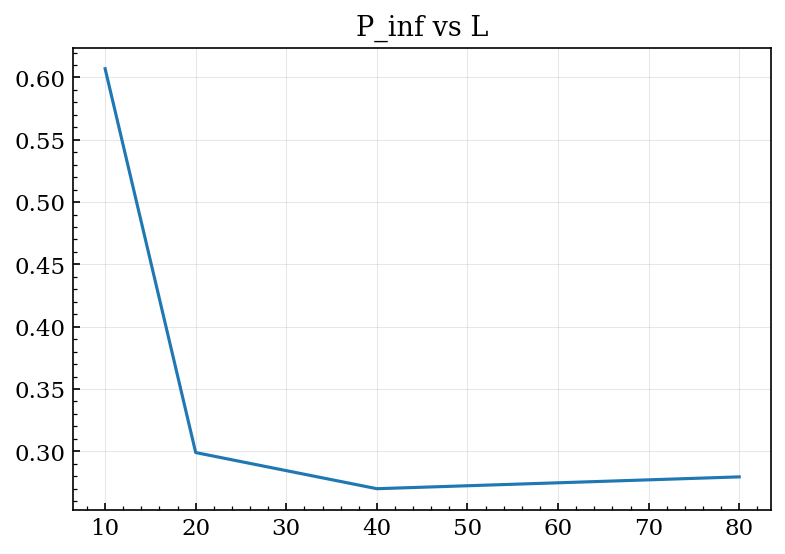

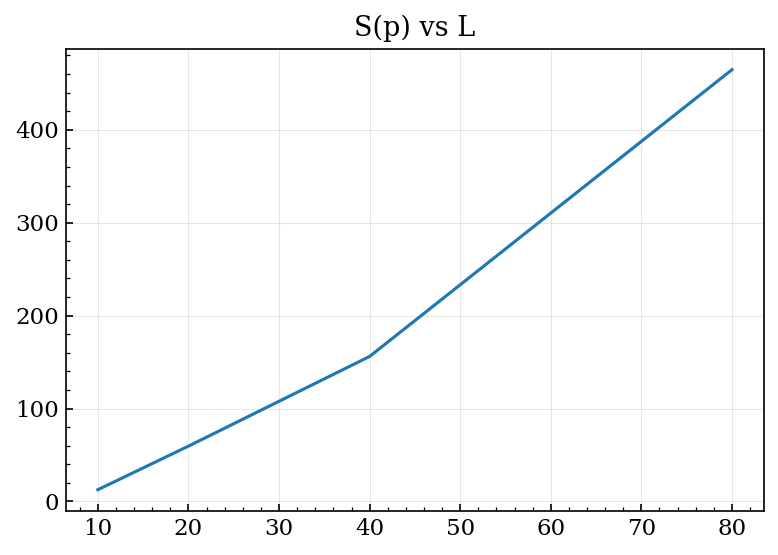

In [119]:
L = np.array([10,20,40,80])
P_inf = np.array([0.607, 0.299, 0.27, 0.2794893198083899])
Sp = np.array([12.673, 59.56, 156.099, 464.6763525476815])
nu = 4/3
def Pinfty(L, beta):
    return L**(-beta/nu)
def Spanal(L, gamma):
    return L**(gamma/nu)
yur1 = sp.optimize.curve_fit(Pinfty, L, P_inf)
yur2 = sp.optimize.curve_fit(Spanal, L ,Sp)
print(yur1,yur2)
plt.figure()
plt.plot(L, P_inf)
plt.title("P_inf vs L")
plt.figure()
plt.title("S(p) vs L")
plt.plot(L, Sp)
